In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier

In [10]:
%pip install xgboost

  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.3.0-py3-none-win_amd64.whl (69.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

df = pd.read_csv(r"E:\Smart-Irrigation-System\data\raw\irrigation_dataset.csv")

In [4]:
X = df.drop(columns=["Irrigation_Need"])
y = df["Irrigation_Need"]

In [5]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

In [6]:
mapping = dict(zip(label_encoder.classes_,
                   label_encoder.transform(label_encoder.classes_)))

print(mapping)

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [8]:
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = X.select_dtypes(include=["object"]).columns

In [9]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_columns),
        ("cat", categorical_pipeline, categorical_columns)
    ]
)

In [10]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [11]:
model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)

In [12]:
model.fit(X_train_processed, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [14]:
y_pred = model.predict(X_test_processed)

In [15]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9960


In [17]:
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

        High       1.00      0.93      0.96        67
         Low       1.00      1.00      1.00      1173
      Medium       0.99      1.00      0.99       760

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.98      2000
weighted avg       1.00      1.00      1.00      2000



In [18]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[  62    0    5]
 [   0 1171    2]
 [   0    1  759]]


In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

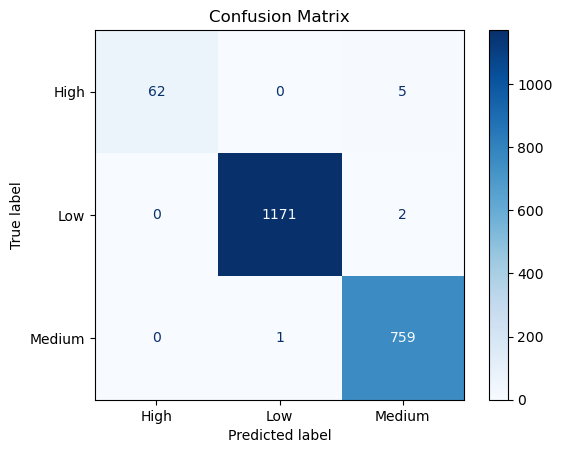

In [20]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [21]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

<Figure size 1200x800 with 0 Axes>

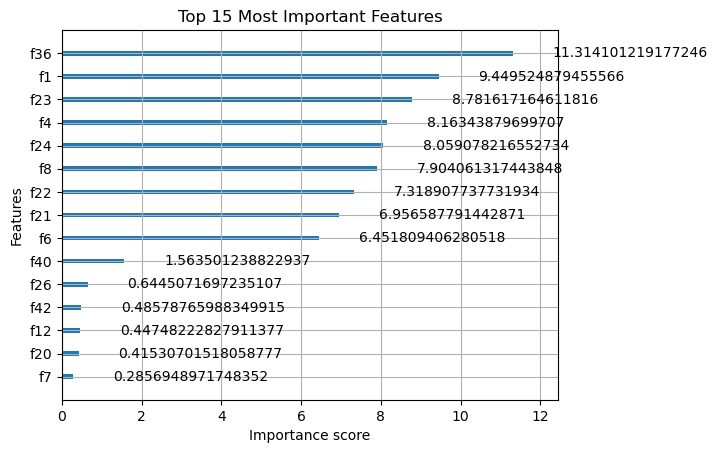

In [22]:
plt.figure(figsize=(12, 8))

plot_importance(
    model,
    max_num_features=15,
    importance_type="gain"
)

plt.title("Top 15 Most Important Features")
plt.show()

In [24]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__Soil_pH' 'num__Soil_Moisture' 'num__Organic_Carbon'
 'num__Electrical_Conductivity' 'num__Temperature_C' 'num__Humidity'
 'num__Rainfall_mm' 'num__Sunlight_Hours' 'num__Wind_Speed_kmh'
 'num__Field_Area_hectare' 'num__Previous_Irrigation_mm'
 'cat__Soil_Type_Clay' 'cat__Soil_Type_Loamy' 'cat__Soil_Type_Sandy'
 'cat__Soil_Type_Silt' 'cat__Crop_Type_Cotton' 'cat__Crop_Type_Maize'
 'cat__Crop_Type_Potato' 'cat__Crop_Type_Rice' 'cat__Crop_Type_Sugarcane'
 'cat__Crop_Type_Wheat' 'cat__Crop_Growth_Stage_Flowering'
 'cat__Crop_Growth_Stage_Harvest' 'cat__Crop_Growth_Stage_Sowing'
 'cat__Crop_Growth_Stage_Vegetative' 'cat__Season_Kharif'
 'cat__Season_Rabi' 'cat__Season_Zaid' 'cat__Irrigation_Type_Canal'
 'cat__Irrigation_Type_Drip' 'cat__Irrigation_Type_Rainfed'
 'cat__Irrigation_Type_Sprinkler' 'cat__Water_Source_Groundwater'
 'cat__Water_Source_Rainwater' 'cat__Water_Source_Reservoir'
 'cat__Water_Source_River' 'cat__Mulching_Used_No'
 'cat__Mulching_Used_Yes' 'cat__Region_Central' '

In [25]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
36,cat__Mulching_Used_No,0.140072
1,num__Soil_Moisture,0.116988
23,cat__Crop_Growth_Stage_Sowing,0.108719
4,num__Temperature_C,0.101066
24,cat__Crop_Growth_Stage_Vegetative,0.099774
8,num__Wind_Speed_kmh,0.097855
22,cat__Crop_Growth_Stage_Harvest,0.090610
21,cat__Crop_Growth_Stage_Flowering,0.086125
6,num__Rainfall_mm,0.079875
40,cat__Region_North,0.019357
